In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

In [2]:
final_results = pd.read_pickle("/home/mattia/Downloads/ALICE/ALL_MC_with_BKG.pkl")

print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 71_693_465 rows and 21 columns.
It occupies 5_811.64 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,...,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,mother_pdg_pos,truth,same_mother
0,-0.000008,1.803016,1.778223,1.575074,0.004660,0.995067,1.014060,-0.055695,-999.0,0.002824,...,1.080044,1.812436,-0.002688,0.413968,-999.0,1.759560,-3.427866,0.0,0,True
1,0.000008,2.215073,2.207963,0.473187,0.013202,0.053475,1.014060,-0.055695,-999.0,0.002824,...,0.829078,-999.000000,0.002763,0.413968,-999.0,1.572557,-999.000000,0.0,0,True
2,-0.000030,2.206993,2.182972,0.957466,0.011976,-0.798503,0.857933,8.520977,-999.0,0.011094,...,1.080044,1.812436,-0.002688,9.819099,-999.0,1.759560,-3.427866,0.0,0,True
3,0.000031,1.077656,1.055248,1.876580,0.016502,-0.898782,0.857933,8.520977,-999.0,0.011094,...,0.829078,-999.000000,0.002763,9.819099,-999.0,1.572557,-999.000000,0.0,0,True
4,-0.000006,1.802861,1.811291,1.872615,0.004316,-0.990615,1.388882,2.086939,-999.0,0.002292,...,1.080044,1.812436,-0.002688,1.018354,-999.0,1.759560,-3.427866,0.0,0,True
71693460,-0.000007,0.817484,0.819815,1.942073,0.027600,-0.992015,0.931452,0.829556,-999.0,-0.006850,...,-0.338925,-5.902093,0.001065,0.190194,-999.0,0.125043,-18.729809,0.0,0,True
71693461,-0.000029,1.276946,1.442003,0.654153,0.484136,0.599167,0.964872,0.921494,-999.0,0.000284,...,-0.598109,-999.000000,-0.103506,0.410306,-999.0,-10.056605,-999.000000,0.0,0,True
71693462,0.000004,2.277966,2.295974,0.220301,0.159155,-0.915865,0.964872,0.921494,-999.0,0.000284,...,0.555073,-999.000000,0.014991,0.410306,-999.0,-0.200770,-999.000000,0.0,0,True
71693463,-0.001381,0.990568,0.992497,0.324600,0.118799,-0.578420,0.317333,-8.562991,-999.0,0.013340,...,-0.598109,-999.000000,-0.103506,1.895879,-999.0,-10.056605,-999.000000,0.0,0,True
71693464,0.000200,1.194881,1.045351,0.706488,0.026848,-0.106647,0.317333,-8.562991,-999.0,0.013340,...,0.555073,-999.000000,0.014991,1.895879,-999.0,-0.200770,-999.000000,0.0,0,True


In [3]:
d0_tot = np.sum( final_results["truth"] == 1 )
anti_d0_tot = np.sum( final_results["truth"] == -1 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( final_results["truth"] == 0  )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       14507
Number of anti-D0:  15105
Number of background pairs: 71_663_853
Fraction of D0 and anti-D0 over total: 0.0413%


# Edit the masks to replicate the cuts done in the real data

In [4]:
# Pair variable cuts: cut on these at the start in order to reduce the following boolean evaluations by reducing the size of the dataframe.
COS_CUT = 0.98
PT_MIN, PT_MAX = 2, 8

pt_mask = final_results["pt"].between(PT_MIN, PT_MAX )
cos_mask = (final_results["cos_pointing"] > COS_CUT)
dca_mask = final_results["dcaXY_product"] < -5e-05

mask =  pt_mask & cos_mask & dca_mask
final_results = final_results[mask]

new_Ka_hyp_neg =  (  final_results["neg_TPCka"].abs() < 2 ) & \
        ( ( (final_results["neg_pt"].between(0, 1.4)) & (final_results["neg_TOFka"].abs() < 4) ) |
          ( (final_results["neg_pt"].between(1.4, 3.0)) & (final_results["neg_TOFka"].abs() < 3) ) |
          ( (final_results["neg_pt"].between(0, 3.0)) & (final_results["neg_TOFka"]==-999) )
        )

new_Ka_hyp_pos =  (  final_results["pos_TPCka"].abs() < 2 ) & \
            ( ( (final_results["pos_pt"].between(0, 1.4)) & (final_results["pos_TOFka"].abs() < 4) ) |
              ( (final_results["pos_pt"].between(1.4, 3.0)) & (final_results["pos_TOFka"].abs() < 3) ) |
              ( (final_results["pos_pt"].between(0, 3.0)) & (final_results["pos_TOFka"]==-999) )
            )

new_Pi_hyp_neg =  (  final_results["neg_TPCpi"].abs() < 2 ) & \
            ( ( (final_results["neg_pt"].between(0, 1.4)) & (final_results["neg_TOFpi"].abs() < 4) ) |
              ( (final_results["neg_pt"].between(1.4, 3.0)) & (final_results["neg_TOFpi"].abs() < 3) ) |
              ( (final_results["neg_pt"].between(0, 3.0)) & (final_results["neg_TOFpi"]==-999) )
            )

new_Pi_hyp_pos =  (  final_results["pos_TPCpi"].abs() < 2 ) & \
            ( ( (final_results["pos_pt"].between(0, 1.4)) & (final_results["pos_TOFpi"].abs() < 4) ) |
              ( (final_results["pos_pt"].between(1.4, 3.0)) & (final_results["pos_TOFpi"].abs() < 3) ) |
              ( (final_results["pos_pt"].between(0, 3.0)) & (final_results["pos_TOFpi"]==-999) )
            )

new_undecided_neg = new_Ka_hyp_neg & new_Pi_hyp_neg
new_undecided_pos = new_Ka_hyp_pos & new_Pi_hyp_pos
new_undecided_hyp = new_undecided_neg & new_undecided_pos

new_Ka_hyp = new_Ka_hyp_neg | new_Ka_hyp_pos
new_Pi_hyp = new_Pi_hyp_pos | new_Pi_hyp_neg

new_D0_sure_hyp = new_Ka_hyp_neg & new_Pi_hyp_pos
new_D0_uncert_hyp = ( (new_undecided_neg & new_Pi_hyp_pos) | (new_undecided_pos & new_Ka_hyp_neg) )
new_D0 = new_D0_sure_hyp | new_D0_uncert_hyp

new_antiD0_sure_hyp = new_Ka_hyp_pos & new_Pi_hyp_neg
new_antiD0_uncert_hyp = ( (new_undecided_neg & new_Ka_hyp_pos) | (new_undecided_pos & new_Pi_hyp_neg) )
new_antiD0 = new_antiD0_sure_hyp | new_antiD0_uncert_hyp

final_results["new_particle"] = np.select( condlist=[new_undecided_hyp, new_D0, new_antiD0 ],
                                choicelist=["Undecided", "D0", "Anti-D0"], default="Bkg" )
signal_mask = final_results["new_particle"] != "Bkg"

final_results = final_results[signal_mask]
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

In [5]:
# MOTHER HYPOTHESIS
mask_d0_hyp         = (final_results["new_particle"] == "D0")
mask_anti_d0_hyp    = (final_results["new_particle"] == "Anti-D0")
mask_both_hyp       = (final_results["new_particle"] == "Undecided")

# Histogram of signal and reflected part data only
# reflected part:
# 1) Truth==-1, misclassified as D0-> anti_mass
wrong_anti_D0 = (final_results["truth"] == -1) & (final_results["new_particle"] == "D0")
# 2) Truth==1, misclassified as anti-D0-> inv_mass
wrong_D0 = (final_results["truth"] == 1) & (final_results["new_particle"] == "Anti-D0")
# 3) Undecided, with the opposite mass correspoding to the truth value
Undecided_D0 = (final_results["truth"] == 1) & (final_results["new_particle"] == "Undecided")
Undecided_Anti_D0 = (final_results["truth"] == -1) & (final_results["new_particle"] == "Undecided")

reflex_data = np.select(condlist = [ wrong_anti_D0 | Undecided_Anti_D0, wrong_D0 | Undecided_D0 ],
                        choicelist = [final_results["inv_mass"], final_results["anti_mass"]])

# signal:
# 1) Truth==1, classified correctly as D0-> inv_mass
correct_D0 = (final_results["truth"] == 1) & (final_results["new_particle"] == "D0")
# 2) Truth==-1, classified correctly as anti-D0-> anti_mass
correct_anti_D0 = (final_results["truth"] == -1) & (final_results["new_particle"] == "Anti-D0")
# 3) Undecided, with the mass corresponding to the proper truth value (can re-use the previous mask)

signal_data = np.select(condlist = [ correct_D0 | Undecided_D0, correct_anti_D0 | Undecided_Anti_D0 ],
                        choicelist = [final_results["inv_mass"], final_results["anti_mass"] ])


# ------------------------- BGK ------------------------------------
# BACKGROUND D0 FROM OTHER DECAYS:
mask_bg_but_D0_hyp = mask_d0_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == 421) & final_results["same_mother"]
mask_bg_but_anti_D0_hyp = mask_anti_d0_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == -421) & final_results["same_mother"]
mask_bg_but_D0_both_hyp = mask_both_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == 421) & final_results["same_mother"]
mask_bg_but_anti_D0_both_hyp = mask_both_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == -421) & final_results["same_mother"]

mass_bg_but_d0_hyp       = final_results.loc[mask_bg_but_D0_hyp, "inv_mass"].values
mass_bg_but_anti_d0_hyp  = final_results.loc[mask_bg_but_anti_D0_hyp, "anti_mass"].values
mass_bg_but_both_hyp     = np.concatenate([
    final_results.loc[mask_bg_but_D0_both_hyp, "inv_mass"].values,
    final_results.loc[mask_bg_but_anti_D0_both_hyp, "anti_mass"].values
])

mass_bg_all_but = np.concatenate([mass_bg_but_d0_hyp, mass_bg_but_anti_d0_hyp, mass_bg_but_both_hyp])
print(f"We have {len(mass_bg_all_but)} bg particles that are D0 or anti-D0 from different decays (withoud reflex component)\n")

# ------------------------------------------------------------------
# BACKGROUND REFLEX D0 FROM OTHER DECAYS:
aaa = mask_d0_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == -421) & final_results["same_mother"]
bbb = mask_anti_d0_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == 421) & final_results["same_mother"]
ccc = mask_both_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == 421) & final_results["same_mother"]
ddd = mask_both_hyp & (final_results["truth"] == 0) & ( final_results["mother_pdg_pos"] == -421) & final_results["same_mother"]

eee       = final_results.loc[aaa, "inv_mass"].values
fff       = final_results.loc[bbb, "anti_mass"].values
ggg       = np.concatenate([
    final_results.loc[ccc, "anti_mass"].values,
    final_results.loc[ddd, "inv_mass"].values
])

mass_bg_all_but_reflex = np.concatenate([eee, fff, ggg])
print(f"We have {len(mass_bg_all_but_reflex)} bg particles that are D0 or anti-D0 from different decays (withoud reflex component)")

We have 918 bg particles that are D0 or anti-D0 from different decays (withoud reflex component)

We have 178 bg particles that are D0 or anti-D0 from different decays (withoud reflex component)


In [6]:
reflex_data = np.concatenate( [reflex_data, mass_bg_all_but_reflex] )

# Ratio N1/N2

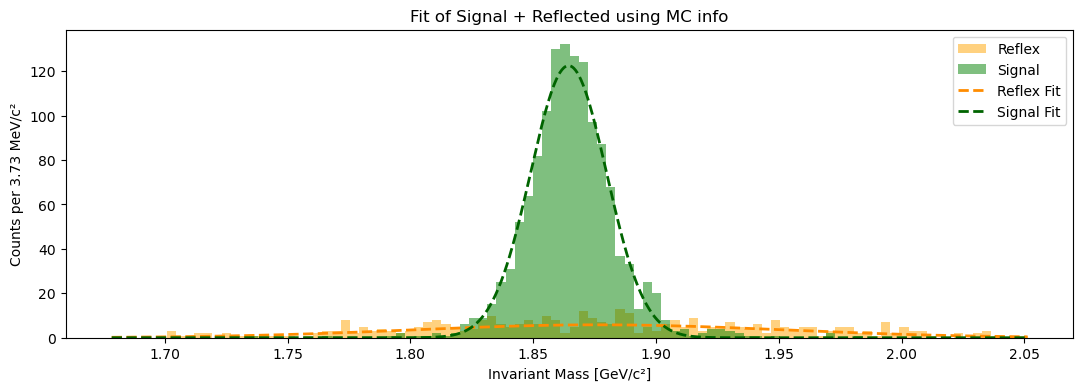


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8644       0.0155        4.747
Reflex             1.8766       0.0757        1.103 

Ratio N1/N2 (reflex/signal):                  0.232 


In [7]:
# --- Fit function: Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# Initializations.
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
binsize = (MAX_MASS - MIN_MASS)/N_BINS

# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
# ------- reflex component:
reflex_counts, reflex_edges, _ = ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
# poisson errors:
sigma_reflex_hist = np.sqrt(reflex_counts)
sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
sign_params = sign_fit_res[0]
mu_sign, sigma_sign = sign_params[1], sign_params[2]
k_sign = sign_params[0]
# ----
reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
reflex_params = reflex_fit_res[0]
mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
k_reflex = reflex_params[0]

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Fit of Signal + Reflected using MC info")
ax.legend()
plt.show()

# PRINT:
ratio_from_fit = k_reflex/k_sign
print("\n================ FIT RESULTS =================")

print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
print("-"*48)
print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
print(f"{'Reflex':<12} {mu_reflex:>12.4f} {sigma_reflex:>12.4f} {k_reflex:>12.3f} \n")

print(f"Ratio N1/N2 (reflex/signal):   {ratio_from_fit:>20.3f} ")

# Ratio N3/N2

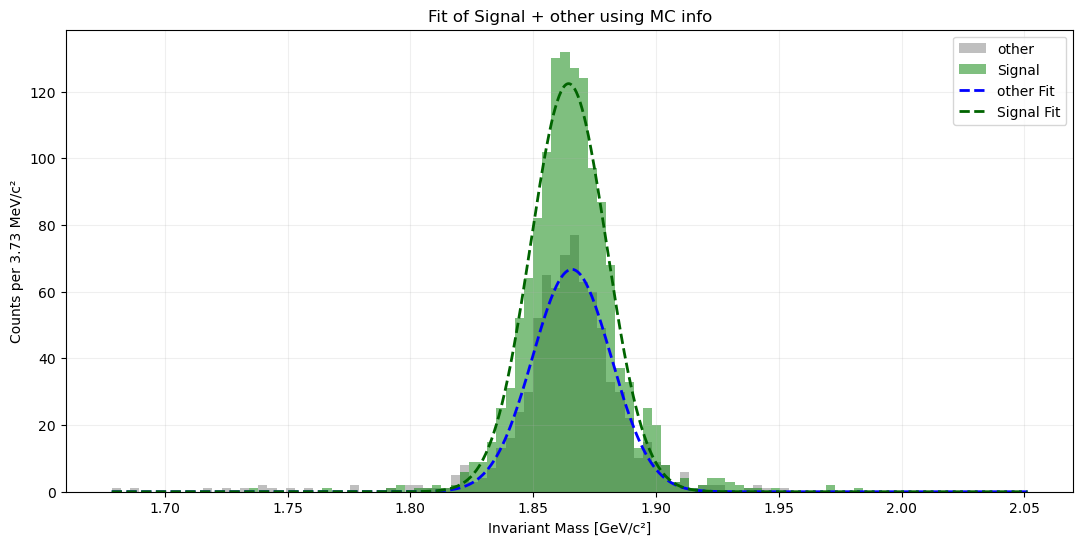


================ FIT RESULTS =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8644       0.0155        4.747
other              1.8657       0.0160        2.674 

Ratio N3/N2 (other/signal):                  0.563 


In [8]:
# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# ------------------------------------------------------------------
# Histogram of TRUE signal and TRUE reflected components

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,6))
# ------- other component:
other_counts, other_edges, _ = ax.hist(mass_bg_all_but, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='other', color='grey')
other_centers = (other_edges[:-1] + other_edges[1:]) / 2.0
# poisson errors:
sigma_other_hist = np.sqrt(other_counts)
sigma_other_hist = np.clip(sigma_other_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
# sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
#                             p0 = [k_param, 
#                                   gauss_params[0], gauss_params[1]
#                                  ]
#                         )
# sign_params = sign_fit_res[0]
# mu_sign, sigma_sign = sign_params[1], sign_params[2]
# k_sign = sign_params[0]
# ----
other_fit_res = curve_fit( fit_gauss_mc, xdata = other_centers, ydata = other_counts, sigma = sigma_other_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
other_params = other_fit_res[0]
mu_other, sigma_other = other_params[1], other_params[2]
k_other = other_params[0]

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_other, mu_other, sigma_other), '--', color='blue', linewidth=2, label='other Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Fit of Signal + other using MC info")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# PRINT:
ratio_from_fit_2 = k_other/k_sign
print("\n================ FIT RESULTS =================")

print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
print("-"*48)
print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
print(f"{'other':<12} {mu_other:>12.4f} {sigma_other:>12.4f} {k_other:>12.3f} \n")

print(f"Ratio N3/N2 (other/signal):   {ratio_from_fit_2:>20.3f} ")

# <center> RESULTS for ratio
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Reflex} + \text{Signal} + \frac{N_3}{N_2} \text{Reflex-others} \right) + \text{Background}
$$

which means, in the linear background example:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Gaussian1} + \text{Gaussian2} + \frac{N_3}{N_2} \text{Gaussian3} \right) + a \cdot x +b
$$

In [9]:
print("\n================ FIT RESULTS: Reflex component =================")

print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
print("-"*48)
print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
print(f"{'Reflex':<12} {mu_reflex:>12.4f} {sigma_reflex:>12.4f} {k_reflex:>12.3f} \n")

print(f"Ratio N1/N2 (reflex/signal):   {ratio_from_fit:>20.3f} ")

print("\n================ FIT RESULTS: Other component =================")

print(f"{'Fit':<12} {'mu':>12} {'sigma':>12} {'k value':>12}")
print("-"*48)
print(f"{'Signal':<12} {mu_sign:>12.4f} {sigma_sign:>12.4f} {k_sign:>12.3f}")
print(f"{'other':<12} {mu_other:>12.4f} {sigma_other:>12.4f} {k_other:>12.3f} \n")

print(f"Ratio N3/N2 (other/signal):   {ratio_from_fit_2:>20.3f} ")


================ FIT RESULTS: Reflex component =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8644       0.0155        4.747
Reflex             1.8766       0.0757        1.103 

Ratio N1/N2 (reflex/signal):                  0.232 

================ FIT RESULTS: Other component =================
Fit                    mu        sigma      k value
------------------------------------------------
Signal             1.8644       0.0155        4.747
other              1.8657       0.0160        2.674 

Ratio N3/N2 (other/signal):                  0.563 


# Extra: Comparison with MC info for fit results

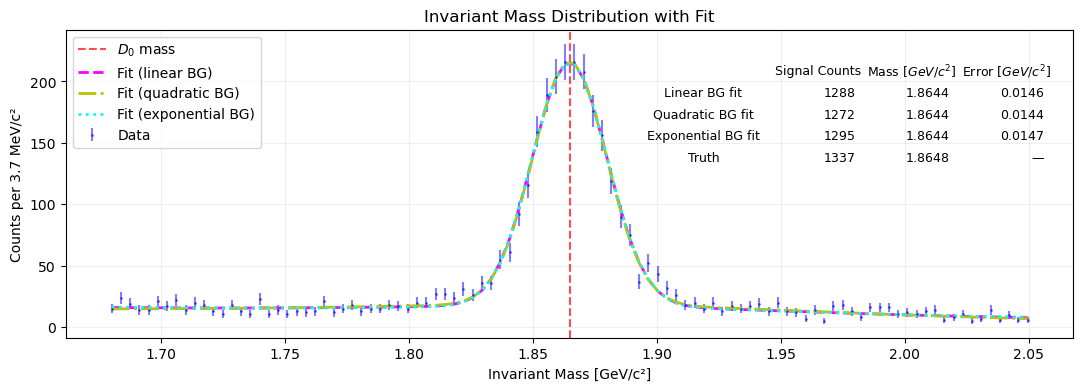


================ FIT RESULTS =================
Fit            N_signal           mu        sigma
------------------------------------------------
Linear             1288     1.864450     0.014641
Quadratic          1272     1.864444     0.014392
Exponential        1295     1.864444     0.014744
truth              1337     1.864840


In [19]:
# --- Fit function: 1 free Gaussian (signal) + 1 FIXED Gaussian (reflex) + linear background ---
ratio = ratio_from_fit   # fixed ratio from previous fit N_reflex/N_signal
ratio2 = ratio_from_fit_2

# --- Fit function: 1 free Gaussian (signal) + 1 FIXED Gaussian (reflex) + linear background ---
def fit_function_lin(x, k, mu1, sigma1, a, b):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    other_part    = norm.pdf(x, loc=mu_other,   scale=sigma_other)
    background   = a*x + b
    return k * ( ratio*reflex_part + signal_part + ratio2*other_part ) + background

# --- Fit function with quadratic background ---
def fit_function_quad(x, k, mu1, sigma1, a2, a1, a0):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    other_part    = norm.pdf(x, loc=mu_other,   scale=sigma_other)
    background   = a2*x**2 + a1*x + a0
    return k * ( ratio*reflex_part + signal_part + ratio2*other_part ) + background

# --- Fit function with exponential background ---
def fit_function_exp(x, k, mu1, sigma1, A, lamb):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    other_part    = norm.pdf(x, loc=mu_other,   scale=sigma_other)
    background   = A * np.exp(lamb * x)
    return k * ( ratio*reflex_part + signal_part + ratio2*other_part ) + background



# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
binsize = (MAX_MASS - MIN_MASS)/N_BINS

# --- Data ---
data = np.concatenate([final_results[final_results["new_particle"]=="D0"]["inv_mass"],
                      final_results[final_results["new_particle"]=="Anti-D0"]["anti_mass"],
                      final_results[final_results["new_particle"]=="Undecided"]["inv_mass"],
                      final_results[final_results["new_particle"]=="Undecided"]["anti_mass"]])

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
both_counts, both_edges = np.histogram(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)
# plot:
ax.errorbar(both_centers, both_counts, yerr=sigma_hist, fmt='.', markersize=2, color='blue', alpha=0.5, label='Data')
ax.axvline(x=m_d0, color="red", ls='--', label=r"$D_0$ mass", alpha=0.7)

# =========================================== FIT =========================================

# Initial parameter guesses
k_param       = 100
signal_params = [m_d0, 0.02]
back_params   = [133, 1000]
quad_back_params = [0.0, 0.0, 25]
exp_back_params  = [25, -0.01]

# LINEAR FIT:
both_fit_res = curve_fit(
    f       = fit_function_lin,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,                # 0: k
        signal_params[0],       # 1: mu1
        signal_params[1],       # 2: sigma1
        back_params[0],         # 3: a
        back_params[1]          # 4: b
    ]
)
both_params = both_fit_res[0]
# k_fit, mu1, sigma1, a_fit, b_fit = both_params

# QUADRATIC FIT:
quad_fit_res = curve_fit(
    f       = fit_function_quad,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,
        signal_params[0],
        signal_params[1],
        *quad_back_params
    ]
)
quad_params = quad_fit_res[0]

# EXPONENTIAL FIT:
exp_fit_res = curve_fit(
    f       = fit_function_exp,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,
        signal_params[0],
        signal_params[1],
        *exp_back_params
    ]
)
exp_params = exp_fit_res[0]


# =================== PLOT FITTED CURVES ========================================

# --- Plot fitted curves ---
ax.plot( both_centers, fit_function_lin(both_centers, *both_params),
         color='magenta', linestyle='dashed', linewidth=2., label='Fit (linear BG)'
)

ax.plot( both_centers, fit_function_quad(both_centers, *quad_params),
         color='y', linestyle='dashdot', linewidth=2, label='Fit (quadratic BG)'
)

ax.plot( both_centers, fit_function_exp(both_centers, *exp_params),
         color='cyan', linestyle='dotted', linewidth=2, label='Fit (exponential BG)'
)

both_params = both_fit_res[0]
k_lin, mu_lin, sigma_lin, a_lin, b_lin = both_params

k_quad, mu_quad, sigma_quad, *_ = quad_params


k_exp, mu_exp, sigma_exp, *_ = exp_params

# COUNT of D0 from the signal Gaussian only:
N_sig_lin =  ( k_lin * (norm.cdf(MAX_MASS, loc=mu_lin, scale=sigma_lin) - norm.cdf(MIN_MASS, loc=mu_lin, scale=sigma_lin)) ) / binsize
N_sig_quad = ( k_quad * (norm.cdf(MAX_MASS, loc=mu_quad, scale=sigma_quad) - norm.cdf(MIN_MASS, loc=mu_quad, scale=sigma_quad)) ) / binsize
N_sig_exp =  ( k_exp * (norm.cdf(MAX_MASS, loc=mu_exp, scale=sigma_exp) - norm.cdf(MIN_MASS, loc=mu_exp, scale=sigma_exp)) ) / binsize

# ======================= TABLE INSIDE PLOT =======================

cell_text = [
    [f"{N_sig_lin:.0f}",  f"{mu_lin:.4f}",  f"{sigma_lin:.4f}"],
    [f"{N_sig_quad:.0f}", f"{mu_quad:.4f}", f"{sigma_quad:.4f}"],
    [f"{N_sig_exp:.0f}",  f"{mu_exp:.4f}",  f"{sigma_exp:.4f}"],
    [f"{int(np.sum(sign_counts))}",       f"{m_d0:.4f}",    "—"]
]

row_labels = [
    "Linear BG fit",
    "Quadratic BG fit",
    "Exponential BG fit",
    "Truth"
]

col_labels = [
    r"Signal Counts",
    r"Mass [$GeV/c^2$]",
    r"Error [$GeV/c^2$]"
]

table = ax.table(
    cellText   = cell_text,
    rowLabels  = row_labels,
    colLabels  = col_labels,
    colLoc     = "center",
    rowLoc     = "center",
    bbox       = [0.70, 0.55, 0.28, 0.35],     # bbox = [x0, y0, width, height] in axes coordinates (0–1)
    edges      = "open"
)
table.auto_set_font_size(False)
table.set_fontsize(9)


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.1f} MeV/c²")
ax.set_title("Invariant Mass Distribution with Fit")
ax.legend(loc='upper left')
ax.grid(alpha=0.2)
plt.show()


# ================================ PRINT RESULTS ==========================================

print("\n================ FIT RESULTS =================")

print(f"{'Fit':<12} {'N_signal':>10} {'mu':>12} {'sigma':>12}")
print("-"*48)
print(f"{'Linear':<12} {N_sig_lin:>10.0f} {mu_lin:>12.6f} {sigma_lin:>12.6f}")
print(f"{'Quadratic':<12} {N_sig_quad:>10.0f} {mu_quad:>12.6f} {sigma_quad:>12.6f}")
print(f"{'Exponential':<12} {N_sig_exp:>10.0f} {mu_exp:>12.6f} {sigma_exp:>12.6f}")
print(f"{'truth':<12} {int(np.sum(sign_counts)):>10} {m_d0:>12.6f}")

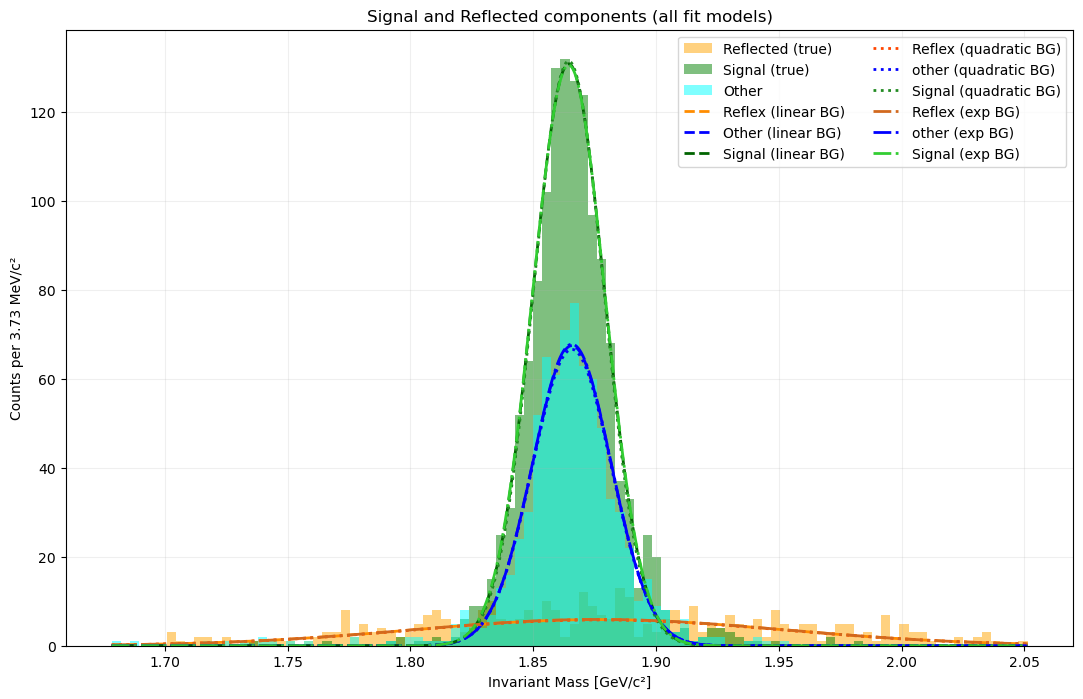

In [18]:
# SECOND PLOT: signal and reflected plot with fixed Gaussian for reflex

fig, ax = plt.subplots(figsize=(13, 8))

# ===================== DATA =====================
# already defines reflex_data and signal_data

# ===================== HISTOGRAMS =====================

ax.hist( reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
    color='orange', alpha=0.5, label='Reflected (true)' )

ax.hist( signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
    color='green', alpha=0.5, label='Signal (true)' )

ax.hist( mass_bg_all_but, bins=N_BINS, range=(MIN_MASS, MAX_MASS),
    color='cyan', alpha=0.5, label='Other' )

# ===================== FITTED CURVES ===================

x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)

# --- Linear BG fit ---
ax.plot( x_fit, k_lin * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
    '--', color='darkorange', linewidth=2, label='Reflex (linear BG)' )

ax.plot( x_fit, k_lin * ratio2 * norm.pdf(x_fit, mu_other, sigma_other),
    '--', color='blue', linewidth=2, label='Other (linear BG)' )

ax.plot( x_fit, k_lin * norm.pdf(x_fit, mu_lin, sigma_lin),
    '--', color='darkgreen', linewidth=2, label='Signal (linear BG)' )

# --- Quadratic BG fit ---
ax.plot( x_fit, k_quad * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
    ':', color='orangered', linewidth=2, label='Reflex (quadratic BG)' )

ax.plot( x_fit, k_quad * ratio2 * norm.pdf(x_fit, mu_other, sigma_other),
    ':', color='blue', linewidth=2, label='other (quadratic BG)' )

ax.plot( x_fit, k_quad * norm.pdf(x_fit, mu_quad, sigma_quad),
    ':', color='forestgreen', linewidth=2, label='Signal (quadratic BG)' )

# --- Exponential BG fit ---
ax.plot( x_fit, k_exp * ratio * norm.pdf(x_fit, mu_reflex, sigma_reflex),
    '-.', color='chocolate', linewidth=2, label='Reflex (exp BG)' )

ax.plot( x_fit, k_exp * ratio2 * norm.pdf(x_fit, mu_other, sigma_other),
    '-.', color='blue', linewidth=2, label='other (exp BG)' )

ax.plot( x_fit, k_exp * norm.pdf(x_fit, mu_exp, sigma_exp),
    '-.', color='limegreen', linewidth=2, label='Signal (exp BG)' )

# ===================== STYLE =====================

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Signal and Reflected components (all fit models)")
ax.legend(ncol=2, fontsize=10)
ax.grid(alpha=0.2)

#plt.tight_layout()
plt.show()